In [1]:
import pandas as pd
df=pd.read_csv("diabetes_prediction_dataset.csv")
print(df) # all samples of datasets with features 
print(type(df)) # for type(DataFrame) of df
print('\n')
print(df.shape) # No of samples(rows) and features(columns)
print('\n')
print(df.info()) # all fbeatures (columns names) with dtype and also total entries(samples or rows)


       gender   age  hypertension  heart_disease smoking_history    bmi  \
0      Female  80.0             0              1           never  25.19   
1      Female  54.0             0              0         No Info  27.32   
2        Male  28.0             0              0           never  27.32   
3      Female  36.0             0              0         current  23.45   
4        Male  76.0             1              1         current  20.14   
...       ...   ...           ...            ...             ...    ...   
99995  Female  80.0             0              0         No Info  27.32   
99996  Female   2.0             0              0         No Info  17.37   
99997    Male  66.0             0              0          former  27.83   
99998  Female  24.0             0              0           never  35.42   
99999  Female  57.0             0              0         current  22.43   

       HbA1c_level  blood_glucose_level  diabetes  
0              6.6                  140        

In [2]:
temp=df[(df['smoking_history']=='never') & (df['diabetes']==1)]
print(temp.shape[0]) 



3346


In [3]:
print(df.describe())



                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000000       0.00000       0.000000      29.580000   
max        80.000000       1.00000       1.000000      95.690000   

         HbA1c_level  blood_glucose_level       diabetes  
count  100000.000000        100000.000000  100000.000000  
mean        5.527507           138.058060       0.085000  
std         1.070672            40.708136       0.278883  
min         3.500000            80.000000       0.000000  
25%         4.800000           100.000000       0.000000  
50%         5.800000           14

In [4]:
print(df.isna().any(axis=1))
print('No of samples having missing values:',df.isna().any(axis=1).sum())



0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool
No of samples having missing values: 0


In [5]:
print(df.head(50))


    gender   age  hypertension  heart_disease smoking_history    bmi  \
0   Female  80.0             0              1           never  25.19   
1   Female  54.0             0              0         No Info  27.32   
2     Male  28.0             0              0           never  27.32   
3   Female  36.0             0              0         current  23.45   
4     Male  76.0             1              1         current  20.14   
5   Female  20.0             0              0           never  27.32   
6   Female  44.0             0              0           never  19.31   
7   Female  79.0             0              0         No Info  23.86   
8     Male  42.0             0              0           never  33.64   
9   Female  32.0             0              0           never  27.32   
10  Female  53.0             0              0           never  27.32   
11  Female  54.0             0              0          former  54.70   
12  Female  78.0             0              0          former  3

In [6]:

print(df.isnull().sum()) # each feature with number of missing values 
#print(df.isna().sum())
# if missing values found
# you can use 
# discrete : df['gender'].fillna(df['gender'].mode()[0])
#continuous : df['age'].fillna(df['age'].median())



gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [7]:
print(df.duplicated())
print("\nNo of duplicated samples are:",df.duplicated().sum())
print(df[df.duplicated()]) # for duplicated samples

# lets go for removing duplicates
df.drop_duplicates(inplace=True)
print('\nAfter removing duplicates')
print(df)



0        False
1        False
2        False
3        False
4        False
         ...  
99995     True
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool

No of duplicated samples are: 3854
       gender   age  hypertension  heart_disease smoking_history    bmi  \
2756     Male  80.0             0              0         No Info  27.32   
3272   Female  80.0             0              0         No Info  27.32   
3418   Female  19.0             0              0         No Info  27.32   
3939   Female  78.0             1              0          former  27.32   
3960     Male  47.0             0              0         No Info  27.32   
...       ...   ...           ...            ...             ...    ...   
99980  Female  52.0             0              0           never  27.32   
99985    Male  25.0             0              0         No Info  27.32   
99989  Female  26.0             0              0         No Info  27.32   
99990    Male  39.0  

In [8]:
min_value=df['blood_glucose_level'].min()
max_value=df['blood_glucose_level'].max()

df['blood_glucose_level']=(df['blood_glucose_level']-min_value)/(max_value-min_value);
print(df['blood_glucose_level'])



0        0.272727
1        0.000000
2        0.354545
3        0.340909
4        0.340909
           ...   
99994    0.295455
99996    0.090909
99997    0.340909
99998    0.090909
99999    0.045455
Name: blood_glucose_level, Length: 96146, dtype: float64


In [9]:

df['gender']=df['gender'].map({
    'Male' : 0,
    'Female' : 1,
    'Other': 2
})
df['smoking_history']=df['smoking_history'].map({
    'never':0,
    'No Info': 1,
    'not current': 2,
    'former': 3,
    'ever': 4,
    'current': 5
})

print(df.head(10))


   gender   age  hypertension  heart_disease  smoking_history    bmi  \
0       1  80.0             0              1                0  25.19   
1       1  54.0             0              0                1  27.32   
2       0  28.0             0              0                0  27.32   
3       1  36.0             0              0                5  23.45   
4       0  76.0             1              1                5  20.14   
5       1  20.0             0              0                0  27.32   
6       1  44.0             0              0                0  19.31   
7       1  79.0             0              0                1  23.86   
8       0  42.0             0              0                0  33.64   
9       1  32.0             0              0                0  27.32   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6             0.272727         0  
1          6.6             0.000000         0  
2          5.7             0.354545         0  
3          5.0 

In [10]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns

outliers_dict={}

for col in numeric_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1;

    lower_bound=Q1-1.5*IQR;
    upper_bound=Q3+1.5*IQR;

    outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)][col]

    outliers_dict[col]={
        'lower_bound':lower_bound,
        'upper_bound':upper_bound,
        'outliers':outliers.values
    }
from pprint import pprint
pprint(outliers_dict)


{'HbA1c_level': {'lower_bound': np.float64(2.6999999999999993),
                 'outliers': array([9. , 9. , 8.8, ..., 9. , 9. , 8.8], shape=(1312,)),
                 'upper_bound': np.float64(8.3)},
 'age': {'lower_bound': np.float64(-28.5),
         'outliers': array([], dtype=float64),
         'upper_bound': np.float64(111.5)},
 'blood_glucose_level': {'lower_bound': np.float64(-0.3113636363636364),
                         'outliers': array([0.81818182, 1.        , 0.90909091, ..., 1.        , 1.        ,
       0.90909091], shape=(2031,)),
                         'upper_bound': np.float64(0.7613636363636364)},
 'bmi': {'lower_bound': np.float64(13.709999999999997),
         'outliers': array([54.7 , 56.43, 63.48, ..., 60.52, 45.15, 40.69], shape=(5354,)),
         'upper_bound': np.float64(39.55)},
 'diabetes': {'lower_bound': np.float64(0.0),
              'outliers': array([1, 1, 1, ..., 1, 1, 1], shape=(8482,), dtype=int64),
              'upper_bound': np.float64(0.0)},
 '

In [11]:
'''ExNo 1 '''
X=df['blood_glucose_level']
y=df['diabetes']

# 1. Split the given dataset into training and testing dataset 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
# 2. Assign the weights and bias using any of the approach (formula or taking random values) 
import numpy as np

x=np.array(X)
y=np.array(y)

n=len(x)
w=(n*np.sum(x*y)-np.sum(x)*np.sum(y))/(n*np.sum(x*x)-(np.sum(x)**2))
b=(np.sum(y) - w * np.sum(x))/n

print('weight:',w)
print('bias:',b)

weight: 0.6471964877185936
bias: -0.08304652111374378


In [13]:
# 3. Write your own code for building the Linear Regression model using the training dataset and predict the target class
def compute_model_output(x,w,b):
    m = x.shape[0]
    f_wb=np.zeros(m)
    for i in range(m):
        f_wb[i]=w*x[i]+b

    return f_wb

def predict_target_class(x, w, b, threshold=0.5):
    y_pred = compute_model_output(x, w, b)
    y_class = np.zeros(len(y_pred))

    for i in range(len(y_pred)):
        if y_pred[i] >= threshold:
            y_class[i] = 1
        else:
            y_class[i] = 0

    return y_class

y_pred=predict_target_class(x,w,b)
print(y_pred)

[0. 0. 0. ... 0. 0. 0.]


In [14]:
# 4. Calculate the Error deviation using test dataset by applying any measures and also find the Accuracy of the model
from sklearn.metrics import mean_squared_error,accuracy_score

x_test_np=np.array(x_test)
y_test_np=np.array(y_test)

y_test_compute=compute_model_output(x_test_np,w,b)
y_test_class=predict_target_class(x_test_np,w,b)
# print(x_test_np)
# print(y_test_np)
# print(y_test_compute)
# print(y_test_class)
mse=mean_squared_error(y_test_np,y_test_compute)
print('mse:',mse)
accuracy=accuracy_score(y_test_np,y_test_class)
print('accuracy:',accuracy)


mse: 0.06659373449894529
accuracy: 0.9243369734789392


In [15]:
# 5. Once the model is built, predict whether a person is diabetic or not for the given blood_glucose_level =155
y_155_pred=w*155 + b
if(y_155_pred>=0.5):
    print("person is diabetic")
else:
    print("person is not diabetic")

person is diabetic


In [16]:
X=df[['blood_glucose_level']]
y=df['diabetes']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

from sklearn.linear_model import LinearRegression
model=LinearRegression()

# print(x_train,y_train)
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

print(y_pred)

y_class=(y_pred>=0.5).astype(int)
print(y_class)

from sklearn.metrics import mean_squared_error,accuracy_score

mse=mean_squared_error(y_test,y_pred)
print('mean_squared_error:',mse)
accuracy=accuracy_score(y_test,y_class)
print('accuracy:',accuracy)

[-0.0531302  -0.06778237  0.32782626 ...  0.09339152  0.10804369
 -0.02382585]
[0 0 0 ... 0 0 0]
mean_squared_error: 0.06659570342287816
accuracy: 0.9243369734789392


In [19]:
X=df.drop('diabetes',axis=1)
y=df['diabetes']

In [20]:
# 1.Split the dataset for training and testing

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [22]:
# 2. Display the intercepts/constant values calculated

from sklearn.linear_model import LinearRegression
model=LinearRegression()

model.fit(x_train,y_train)
print("Intercept value:",model.intercept_)

Intercept value: -0.6860371836329726


In [42]:
# 3.Calculate the accuracy of the model

y_pred=model.predict(x_test)
y_pred_class=(y_pred>=0.5).astype(int)

from sklearn.metrics import mean_squared_error,accuracy_score
mse=mean_squared_error(y_test,y_pred)

accuracy=accuracy_score(y_test,y_pred_class)

print('mean squared error:',mse)
print('accuracy:',accuracy)

mean squared error: 0.052654496937202866
accuracy: 0.9373374934997399


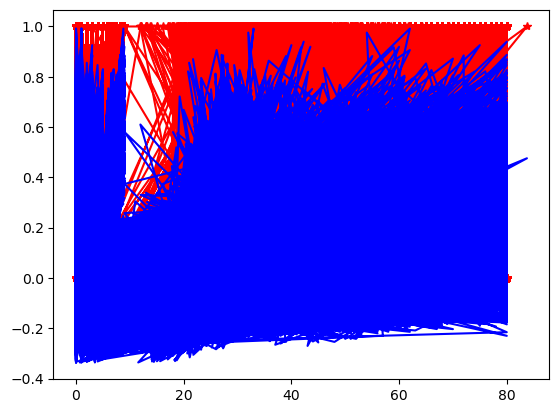

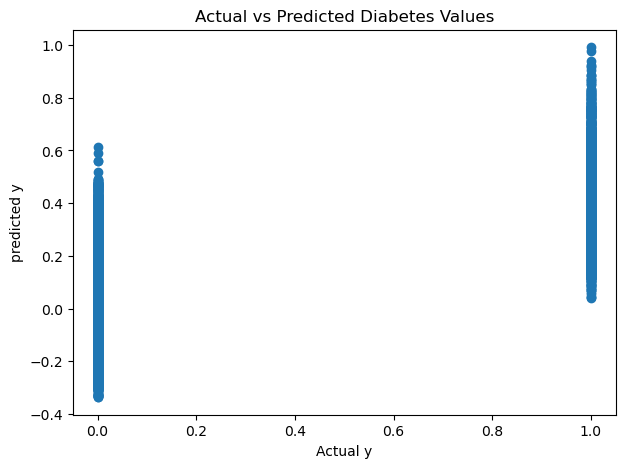

In [36]:
# 4. Draw the comparison graph with y and predicted y

import matplotlib.pyplot as plt
plt.plot(x_test,y_test,c='r',marker='*')
plt.plot(x_test,y_pred,c='b')
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(y_test,y_pred)
plt.xlabel('Actual y')
plt.ylabel('predicted y')
plt.title('Actual vs Predicted Diabetes Values')           
plt.show()

In [61]:
# 5. Predict the person is diabetic or not for the new input feature “Female,36,0,0,current,32.27,6.2,220”  
#encoding female- 0 , smoking _history(cuurent)-5
x_new_test=np.array([[1,36,0,0,5,32.27,6.2,220]])

y_pred_new=model.predict(x_new_test)
if(y_pred_new>=0.5):
    print('Diabetes Status:Diabetic')
else:
    print('Diabetes Status:Not Diabetic')

/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Diabetes Status:Diabetic


In [43]:
print(df)

       gender   age  hypertension  heart_disease  smoking_history    bmi  \
0           1  80.0             0              1                0  25.19   
1           1  54.0             0              0                1  27.32   
2           0  28.0             0              0                0  27.32   
3           1  36.0             0              0                5  23.45   
4           0  76.0             1              1                5  20.14   
...       ...   ...           ...            ...              ...    ...   
99994       1  36.0             0              0                1  24.60   
99996       1   2.0             0              0                1  17.37   
99997       0  66.0             0              0                3  27.83   
99998       1  24.0             0              0                0  35.42   
99999       1  57.0             0              0                5  22.43   

       HbA1c_level  blood_glucose_level  diabetes  
0              6.6             0.27

In [46]:
# 1. Split the dataset for training and testing
X=df.drop('diabetes',axis=1)
y=df['diabetes']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [54]:
# 2. Build and Test the model
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)

model.fit(x_train,y_train)

y_pred=model.predict(x_test)
print(y_pred)

y_pred_prob=model.predict_proba(x_test)[:,1]
print(y_pred_prob)


[0 0 1 ... 0 0 0]
[5.22018733e-06 2.66797762e-03 8.80828416e-01 ... 2.00422007e-04
 2.40033639e-04 1.89371701e-06]


In [56]:
# 3. Evaluate the model using confusion matrix and other measures. Also, Calculate the accuracy of the model 
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

cm=confusion_matrix(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print('Confusion matrix:',cm)
print('Accuracy:',accuracy)
print("Precision:",precision)
print('Recall:',recall)
print('f1_score:',f1)

Confusion matrix: [[17327   182]
 [  647  1074]]
Accuracy: 0.9568902756110245
Precision: 0.8550955414012739
Recall: 0.6240557815223707
f1_score: 0.7215317433658045


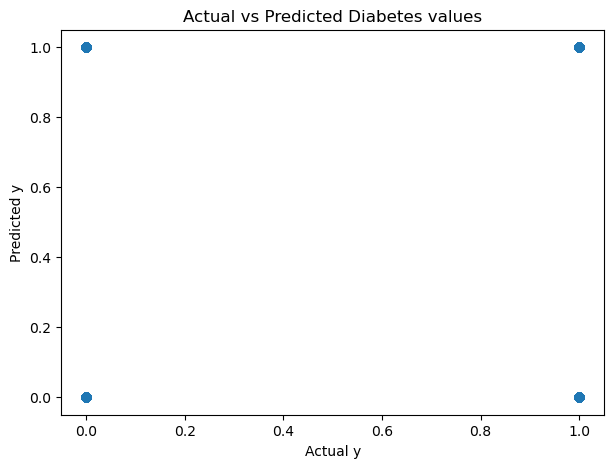

In [58]:
# 4.Draw the comparison graph with y and predicted y

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test,y_pred)
plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.title('Actual vs Predicted Diabetes values')
plt.show()

In [65]:
# 5.Predict the person is diabetic or not for the new input feature  “Male,80,0,0,never,22.06,9,155”
x_new_test=np.array([[0,80,0,0,0,22.06,9,155]])

y_pred_new=model.predict(x_new_test)

if(y_pred_new==1):
    print('Diabetes Status:Diabetic')
else:
    print('Diabetes Status:Not Diabetic')

/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Diabetes Status:Diabetic
